In [2]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load data 
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 191174 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

In [4]:
# split in conditions 
adata_control = adata[adata.obs['condition'] == 'Control'].copy()
adata_IFN_gamma = adata[adata.obs['condition'] == 'IFNγ'].copy()
adata_co_culture = adata[adata.obs['condition'] == 'Co-culture'].copy()

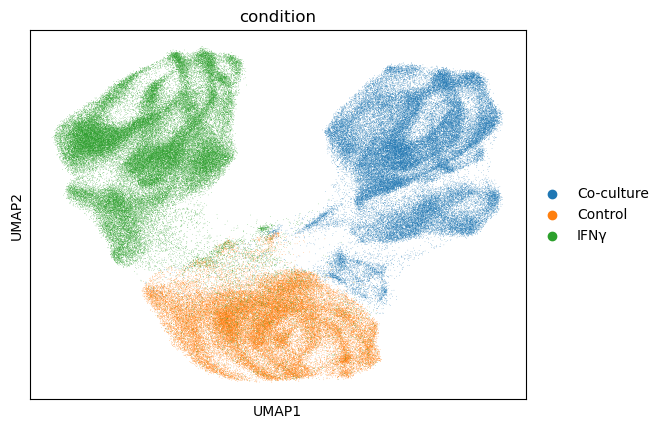

In [16]:
# UMAP over all data
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color="condition")

## Pseudo Bulk mean expression profiles per KO

In [5]:
# calculate pseudo-bulk: mean profile per pertubation group
pertubation_bulk_adata = sc.get.aggregate(adata, by=['condition', 'perturbation'], func='mean')
pertubation_bulk_adata.X = pertubation_bulk_adata.layers['mean'].copy()

df_expr = pertubation_bulk_adata.to_df()
df_obs = pertubation_bulk_adata.obs

In [7]:
print(df_obs)

                   condition perturbation  n_obs_aggregated
Co-culture_A2M    Co-culture          A2M               380
Co-culture_ACSL3  Co-culture        ACSL3               164
Co-culture_ACTA2  Co-culture        ACTA2               392
Co-culture_AEBP1  Co-culture        AEBP1               347
Co-culture_AGA    Co-culture          AGA               340
...                      ...          ...               ...
IFNγ_VDAC2              IFNγ        VDAC2               193
IFNγ_WBP2               IFNγ         WBP2               226
IFNγ_WNT7A              IFNγ        WNT7A               240
IFNγ_XAGE1A             IFNγ       XAGE1A               143
IFNγ_control            IFNγ      control             20192

[747 rows x 3 columns]


## calculate LFC

In [6]:
# log2 Fold change 
ctrl_rows = df_obs[df_obs['perturbation'] == 'control'] # per condition unperturbed cells

# mean gene expression from control cell (no pertubation)
ctrl_control = df_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Control'].index].mean()
ctrl_IFN_gamma = df_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'IFNγ'].index].mean()
ctrl_co_culture = df_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Co-culture'].index].mean()

# get cells with pertubations 
non_ctrl_obs = df_obs[df_obs['perturbation'] != 'control'].copy()
non_ctrl_expr = df_expr.loc[non_ctrl_obs.index].copy()

# substracting baseline condition profile from expression of knockout per condition
for idx in non_ctrl_obs.index:
    condition = non_ctrl_obs.loc[idx, 'condition']
    if condition == 'Control':
        non_ctrl_expr.loc[idx] -= ctrl_control
    elif condition == 'IFNγ':
        non_ctrl_expr.loc[idx] -= ctrl_IFN_gamma
    elif condition == 'Co-culture':
        non_ctrl_expr.loc[idx] -= ctrl_co_culture

log_fold_change_adata = ad.AnnData(X=non_ctrl_expr.values, obs=non_ctrl_obs, var=pertubation_bulk_adata.var.copy())    

# FEATURE SELECTION: filter for HVGs 
log_fold_change_adata_hvg = log_fold_change_adata[:, log_fold_change_adata.var['highly_variable']].copy()


In [10]:
print(log_fold_change_adata_hvg)

AnnData object with n_obs × n_vars = 744 × 2000
    obs: 'condition', 'perturbation', 'n_obs_aggregated'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'


In [7]:
# LFC per condition seperate
log_fold_change_control_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()
log_fold_change_IFN_gamma_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'IFNγ'].copy()
log_fold_change_co_culture_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Co-culture'].copy()

## PCA and leiden clustering all conditions

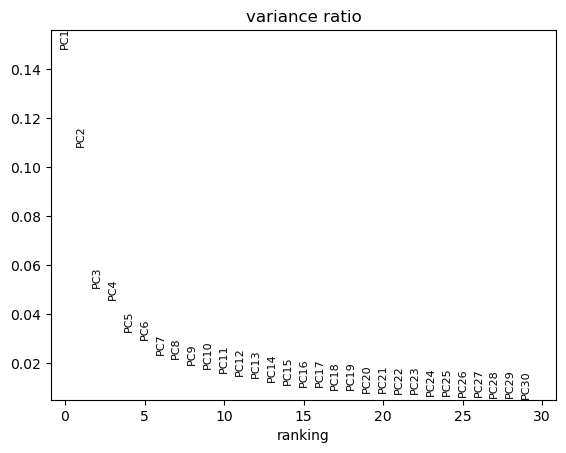

In [8]:
# PCA (on LFC of all HVGs)
sc.pp.pca(log_fold_change_adata_hvg, n_comps=30)
sc.pl.pca_variance_ratio(log_fold_change_adata_hvg, n_pcs=30, log=False)

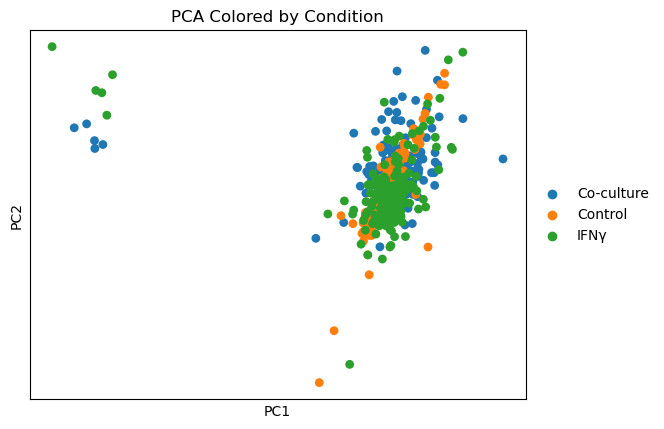

In [9]:
# reduce to 7 PCAs
sc.pp.pca(log_fold_change_adata_hvg, n_comps=7)
sc.pl.pca(log_fold_change_adata_hvg, color='condition', title="PCA Colored by Condition")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


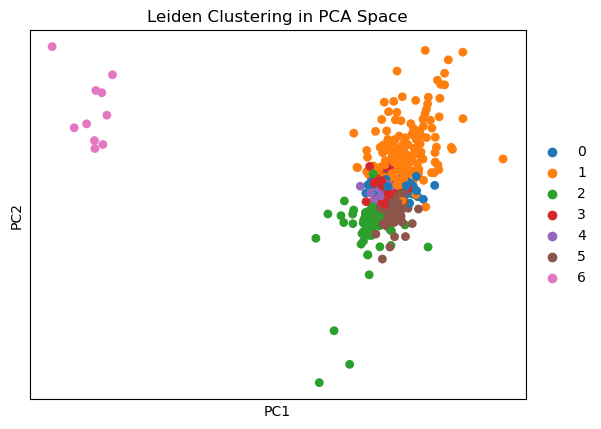

In [11]:
# Neighbors & Leiden Clustering
sc.pp.neighbors(log_fold_change_adata_hvg, use_rep='X_pca')
sc.tl.leiden(log_fold_change_adata_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

sc.pl.pca(log_fold_change_adata_hvg, color='leiden', title="Leiden Clustering in PCA Space")

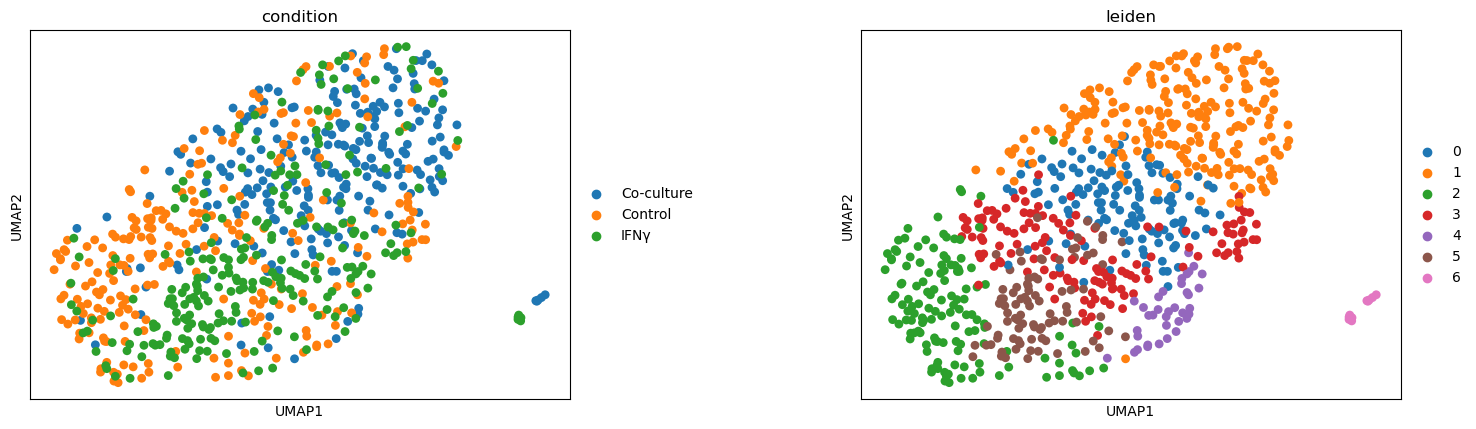

In [12]:
# UMAP (on PCs)
sc.tl.umap(log_fold_change_adata_hvg)
sc.pl.umap(log_fold_change_adata_hvg, color=['condition', 'leiden'], wspace=0.4)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

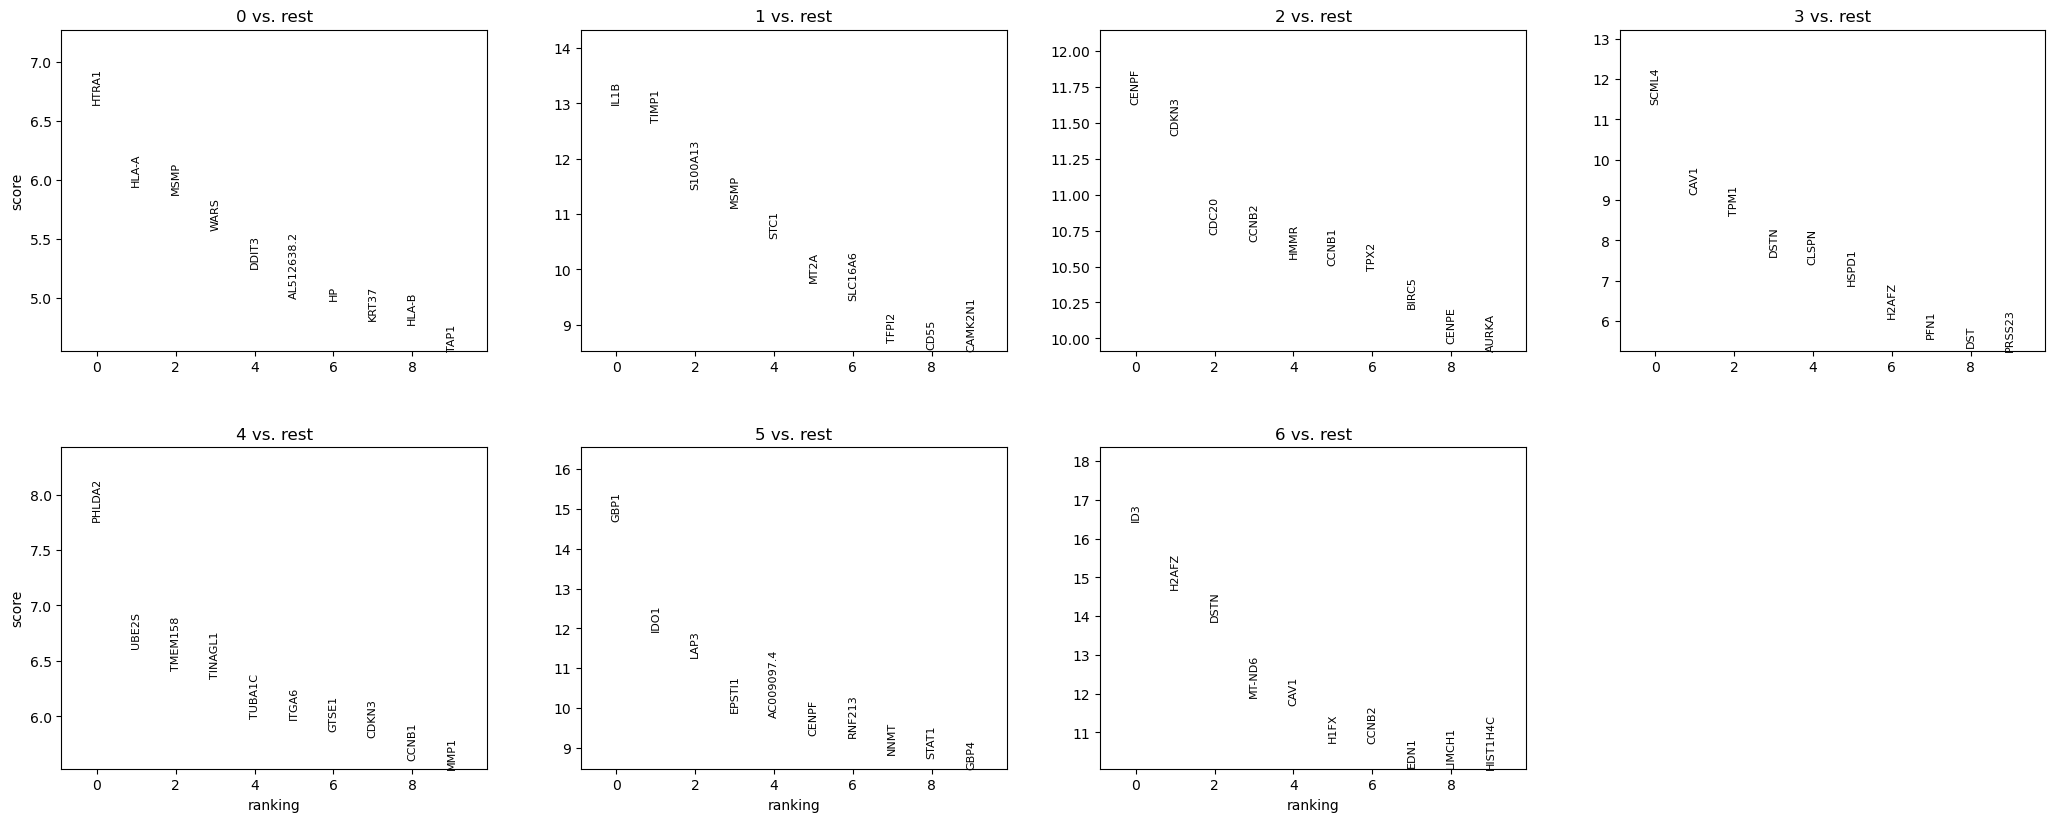

In [13]:
# driver genes 
# genes, which LFC values are most specific for a leiden cluster
log_fold_change_adata_hvg.obs['leiden'] = log_fold_change_adata_hvg.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(log_fold_change_adata_hvg, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(log_fold_change_adata_hvg, n_genes=10, sharey=False)

In [14]:
# pertubations
for cluster_id in log_fold_change_adata_hvg.obs['leiden'].unique():
    perts = log_fold_change_adata_hvg.obs[log_fold_change_adata_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 126) ---
['A2M', 'ACTA2', 'AGA', 'APOD', 'C1QBP', 'C6orf226', 'C19orf48', 'CCND1', 'CD44', 'CD47', 'CD63', 'CD151', 'CDH19', 'CDK6', 'CDKN1A']

--- Cluster 1 (Total: 220) ---
['ACSL3', 'AEBP1', 'AHCY', 'AHNAK', 'APOC2', 'APOE', 'ARMC6', 'ATP1A1', 'ATP1B1', 'B2M', 'BOLA2', 'BOLA2B', 'BZW2', 'CCR10', 'CCT3']

--- Cluster 2 (Total: 131) ---
['ATP5MD', 'CCND2', 'DNAJC9', 'EIF2S3', 'PPA1', 'PRELID3B', 'PSMA7', 'TMEM173', 'TP53', 'TTLL1', 'TXNDC17', 'UQCRH', 'AEBP1', 'ARMC6', 'ATP1A1']

--- Cluster 4 (Total: 36) ---
['CDKN2B', 'FGFR1', 'HLA-B', 'RRS1', 'STAT3', 'AHNAK', 'APOE', 'CDKN2B', 'FGFR1', 'FRZB', 'IFNGR2', 'LY96', 'NCL', 'NME1', 'RPSA']

--- Cluster 5 (Total: 88) ---
['CTSD', 'KCNN4', 'LRRC75A-AS1', 'RB1', 'RUVBL2', 'SNHG6', 'SPESP1', 'AEBP1', 'APOE', 'CCR10', 'CCT6A', 'CD47', 'CD58', 'CDH19', 'CDK4']

--- Cluster 3 (Total: 133) ---
['GPATCH4', 'GPNMB', 'LCP1', 'NMRK1', 'PPIA', 'SET', 'ACTA2', 'AGA', 'APOC2', 'APOD', 'ATP5MD', 'B2M', 'C6orf226', 'C19orf48', 'CC

## clustering per condition

### 1. control

In [15]:
lfc_control = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()

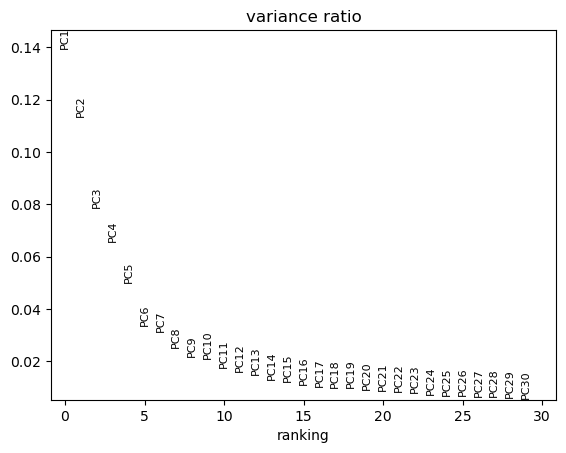

In [16]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_control, n_comps=30)
sc.pl.pca_variance_ratio(lfc_control, n_pcs=30, log=False)

In [17]:
# reduce to 8 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_control, n_comps=8)
sc.pp.neighbors(lfc_control, use_rep='X_pca')
sc.tl.leiden(lfc_control, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

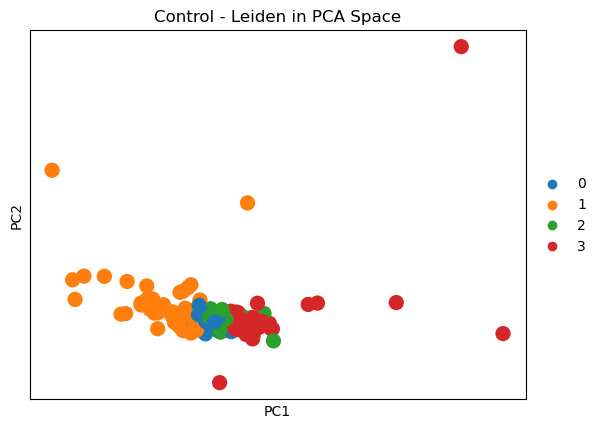

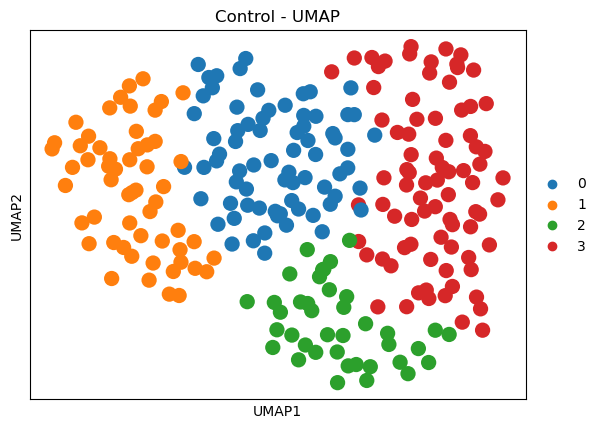

In [18]:
# visualization 
sc.pl.pca(lfc_control, color='leiden', title="Control - Leiden in PCA Space")
sc.tl.umap(lfc_control)
sc.pl.umap(lfc_control, color='leiden', title="Control - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


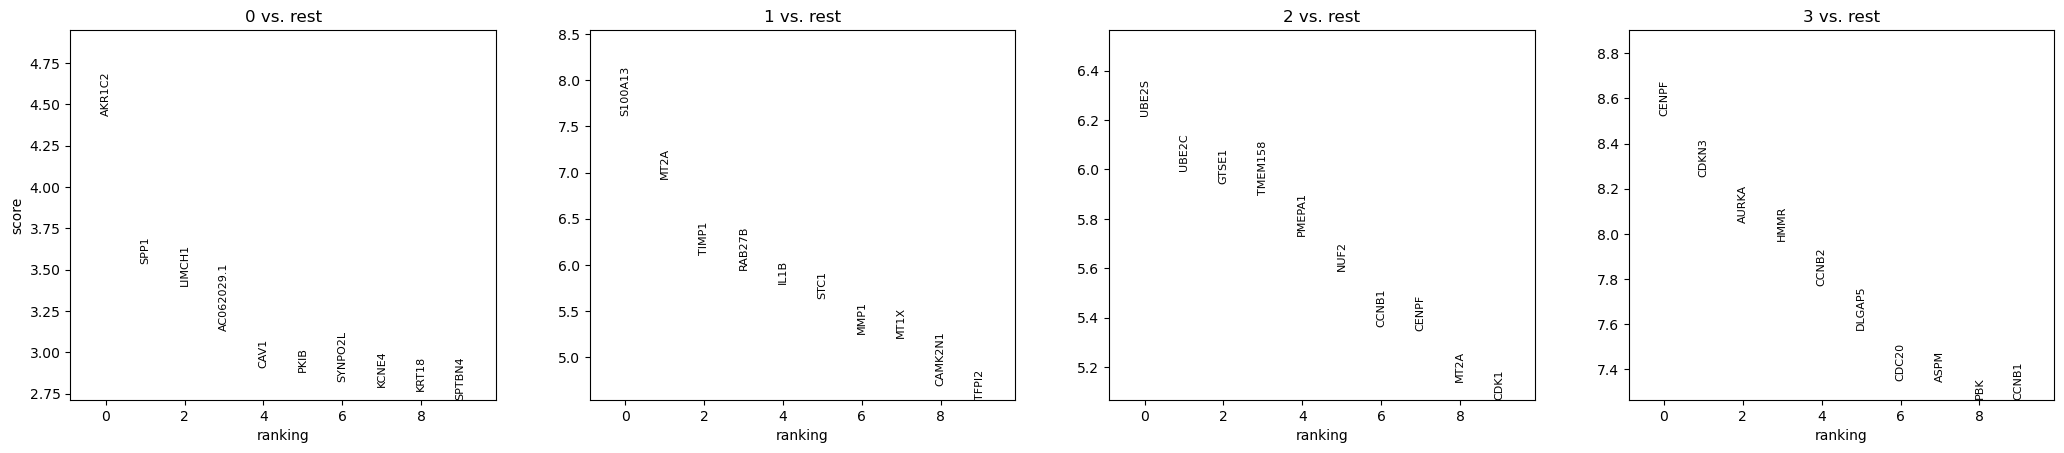

In [19]:
# driver genes 
lfc_control.obs['leiden'] = lfc_control.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_control, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_control, n_genes=10, sharey=False)

In [20]:
# pertubations
for cluster_id in lfc_control.obs['leiden'].unique():
    perts = lfc_control.obs[lfc_control.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 72) ---
['A2M', 'APOC2', 'ATP1B1', 'ATP5MD', 'BOLA2', 'C6orf226', 'C19orf48', 'CCR10', 'CD44', 'CD47', 'CD59', 'CD63', 'CD274', 'CDC123', 'CDH19']

--- Cluster 1 (Total: 56) ---
['ACSL3', 'AGA', 'AHCY', 'APOD', 'B2M', 'BOLA2B', 'BZW2', 'CCND1', 'CCT3', 'CCT6A', 'CDK4', 'CDK6', 'CKS1B', 'CST3', 'CTPS1']

--- Cluster 2 (Total: 39) ---
['ACTA2', 'AHNAK', 'APOE', 'CCND2', 'CDKN2B', 'CTSB', 'CTSO', 'DDX17', 'DNMT1', 'FBL', 'FGFR1', 'FRZB', 'GAA', 'HLA-A', 'HLA-H']

--- Cluster 3 (Total: 81) ---
['AEBP1', 'ARMC6', 'ATP1A1', 'C1QBP', 'CD58', 'CD151', 'CDKN1A', 'CDKN2A', 'CITED1', 'CTSD', 'CXCR4', 'CYP27A1', 'DLL3', 'EIF2S3', 'EIF3K']


### 2. IFN-gamma

In [21]:
lfc_IFN_gamma = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'IFNγ'].copy()

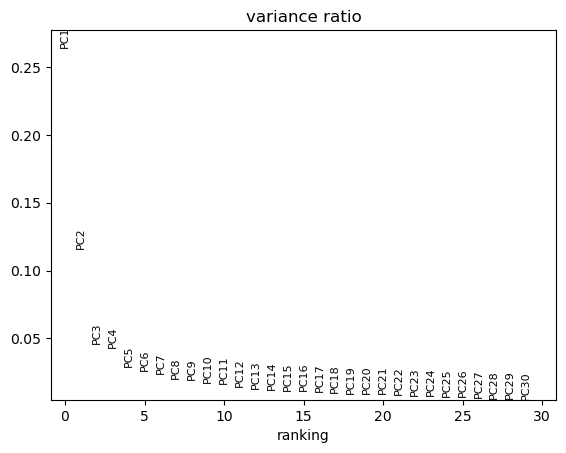

In [22]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_IFN_gamma, n_comps=30)
sc.pl.pca_variance_ratio(lfc_IFN_gamma, n_pcs=30, log=False)

In [23]:
# reduce to 5 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_IFN_gamma, n_comps=5)
sc.pp.neighbors(lfc_IFN_gamma, use_rep='X_pca')
sc.tl.leiden(lfc_IFN_gamma, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

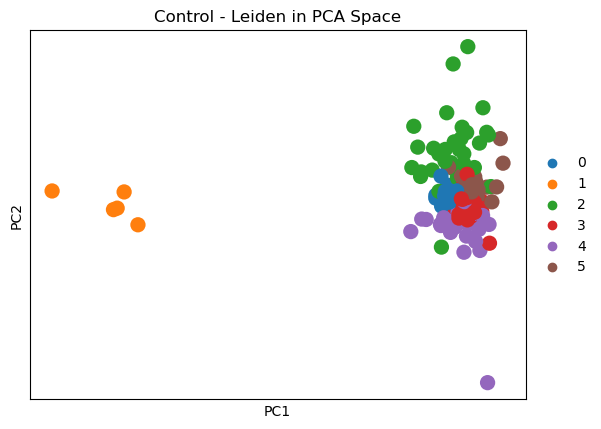

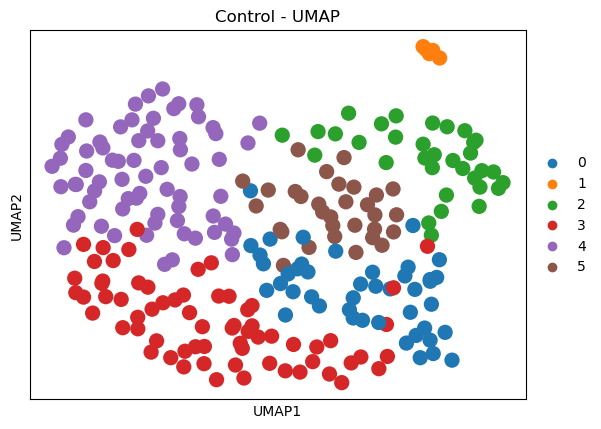

In [24]:
# visualization 
sc.pl.pca(lfc_IFN_gamma, color='leiden', title="Control - Leiden in PCA Space")
sc.tl.umap(lfc_IFN_gamma)
sc.pl.umap(lfc_IFN_gamma, color='leiden', title="Control - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

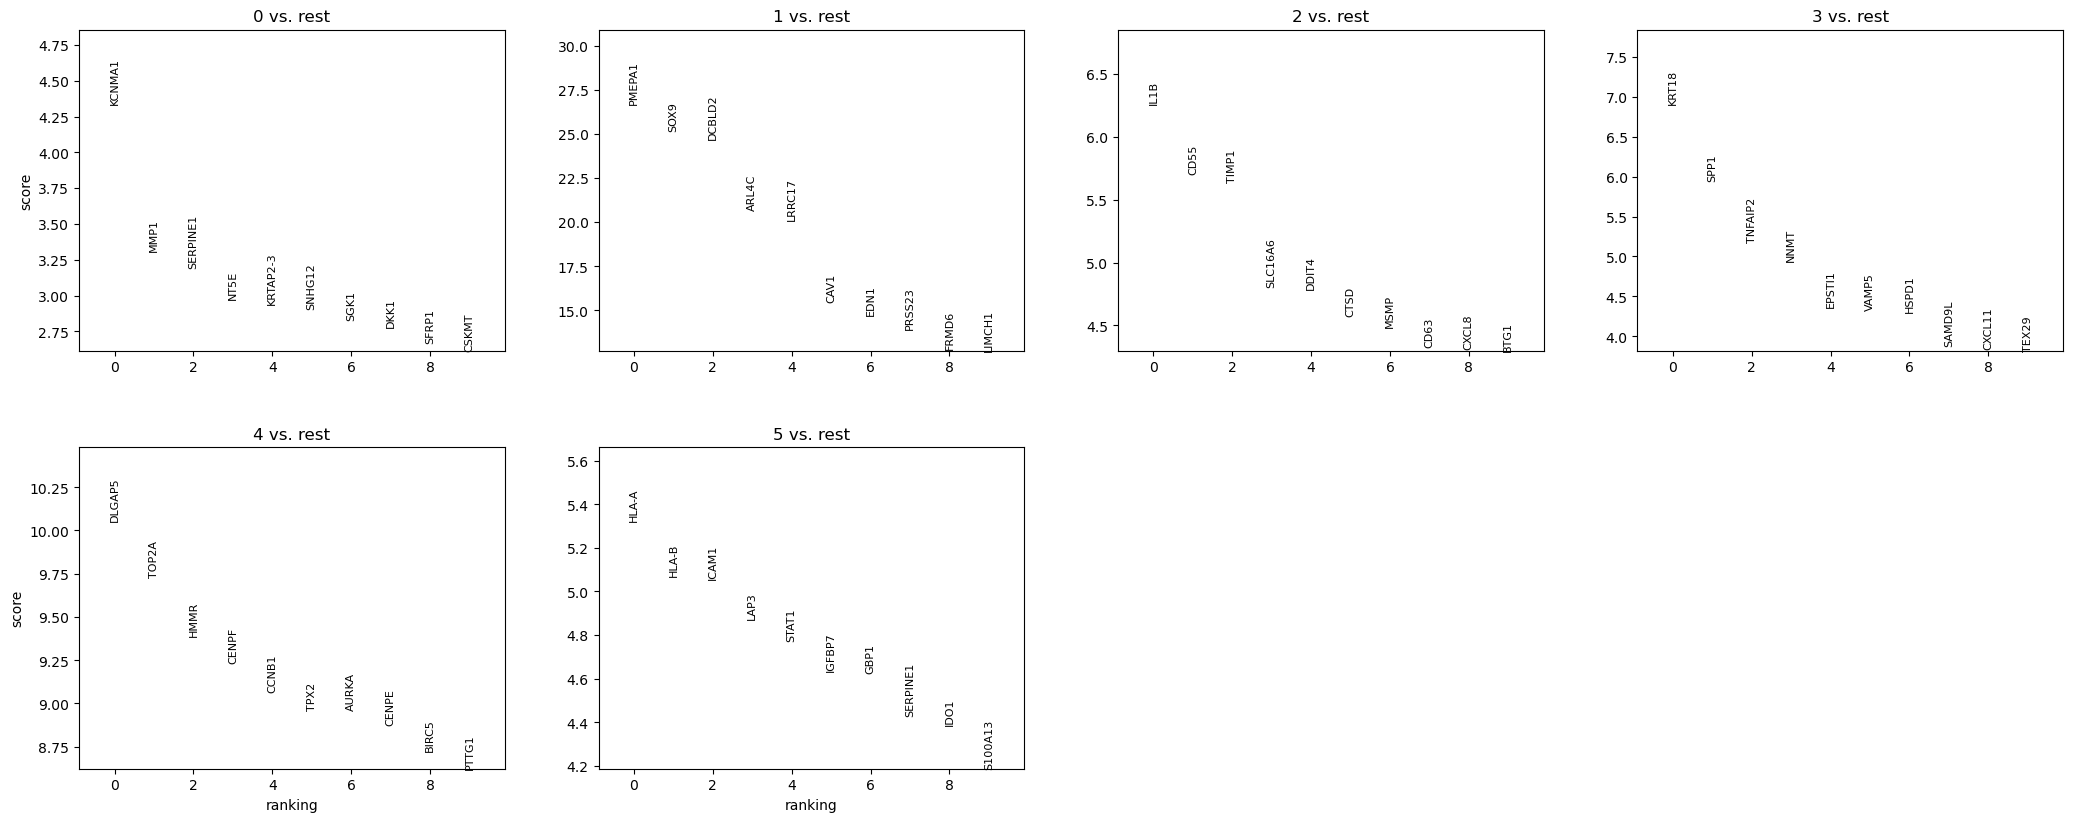

In [25]:
# driver genes 
lfc_IFN_gamma.obs['leiden'] = lfc_IFN_gamma.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_IFN_gamma, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_IFN_gamma, n_genes=10, sharey=False)

In [26]:
# pertubations
for cluster_id in lfc_IFN_gamma.obs['leiden'].unique():
    perts = lfc_IFN_gamma.obs[lfc_IFN_gamma.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 44) ---
['A2M', 'ACTA2', 'ATP1B1', 'BOLA2', 'C6orf226', 'CD63', 'CD151', 'CD274', 'CDC123', 'CDKN2A', 'CORO1A', 'CSPG4', 'CTSD', 'CYP27A1', 'DAG1']

--- Cluster 2 (Total: 33) ---
['ACSL3', 'AHCY', 'CCND1', 'CDK6', 'CKS1B', 'CTPS1', 'DNAJC9', 'DNMT1', 'EEF1G', 'EIF2S3', 'EIF4A1', 'FARSA', 'FMN1', 'FTH1', 'GPI']

--- Cluster 3 (Total: 66) ---
['AEBP1', 'APOC2', 'ARMC6', 'ATP5MD', 'B2M', 'BOLA2B', 'CCR10', 'CD59', 'CDK4', 'CTSA', 'CTSO', 'CXCR4', 'E2F1', 'EMP1', 'ENPP1']

--- Cluster 4 (Total: 69) ---
['AGA', 'APOE', 'ATP1A1', 'C19orf48', 'CCT6A', 'CD47', 'CD58', 'CDH19', 'CDKN1A', 'CDKN2B', 'CGAS', 'CMSS1', 'CTSB', 'CTSL', 'DDR1']

--- Cluster 5 (Total: 31) ---
['AHNAK', 'APOD', 'BZW2', 'C1QBP', 'CCND2', 'CCT3', 'CD44', 'CHCHD2', 'CITED1', 'CST3', 'EVA1A', 'IRF4', 'LEF1-AS1', 'LGALS3BP', 'MYC']

--- Cluster 1 (Total: 5) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']


### 3. co-culture

In [28]:
lfc_co_culture = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Co-culture'].copy()

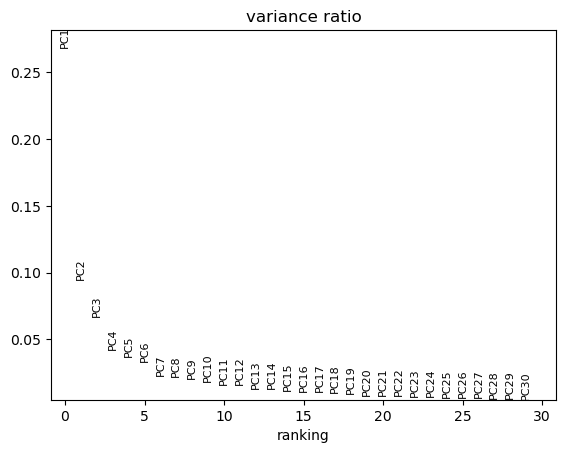

In [29]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_co_culture, n_comps=30)
sc.pl.pca_variance_ratio(lfc_co_culture, n_pcs=30, log=False)

In [30]:
# reduce to 7 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_co_culture, n_comps=8)
sc.pp.neighbors(lfc_co_culture, use_rep='X_pca')
sc.tl.leiden(lfc_co_culture, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

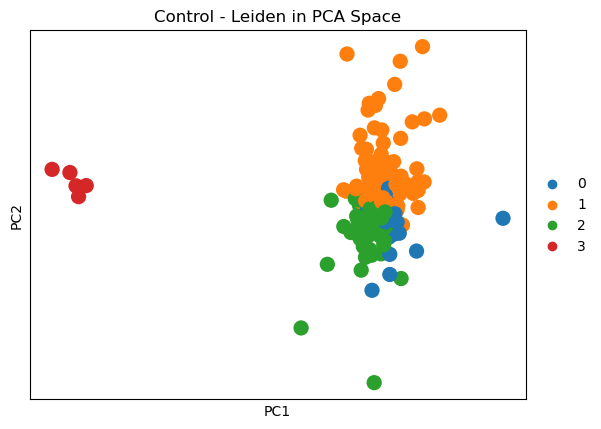

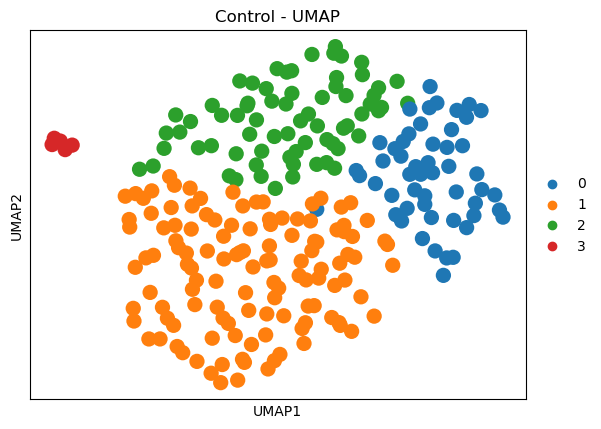

In [31]:
# visualization 
sc.pl.pca(lfc_co_culture, color='leiden', title="Control - Leiden in PCA Space")
sc.tl.umap(lfc_co_culture)
sc.pl.umap(lfc_co_culture, color='leiden', title="Control - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


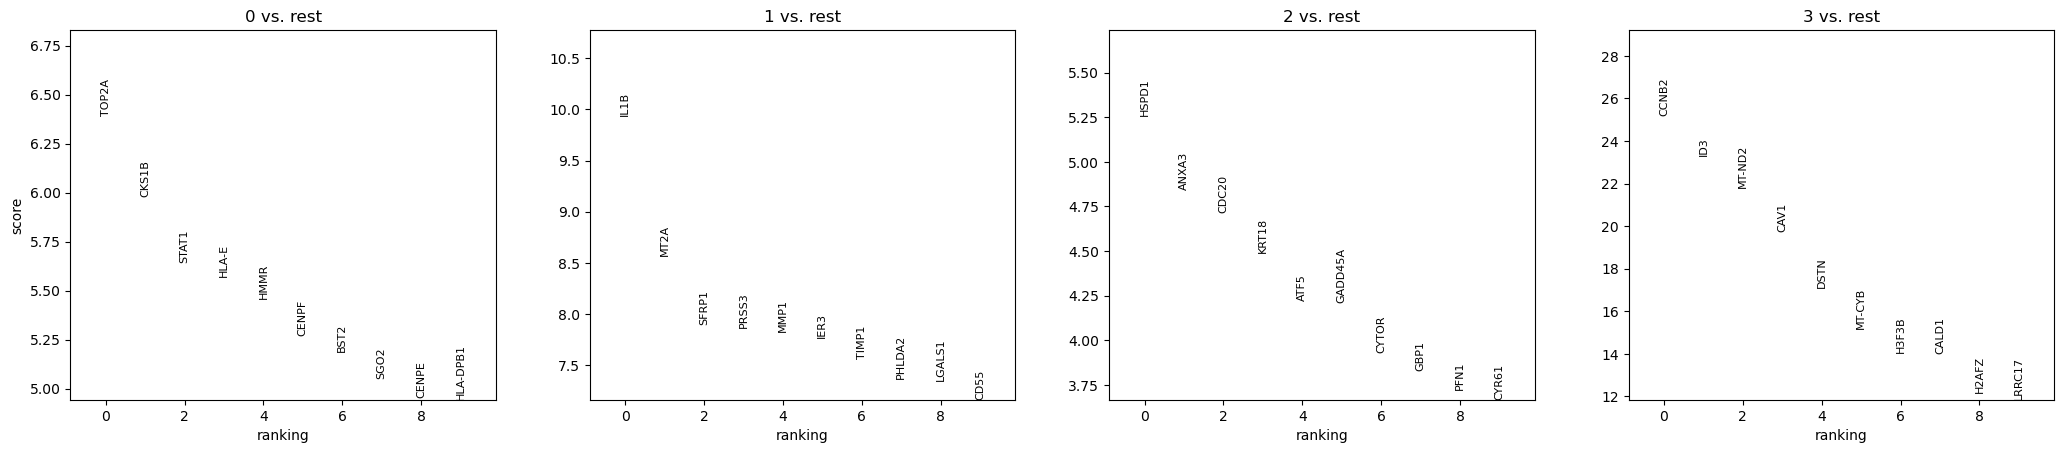

In [32]:
# driver genes 
lfc_co_culture.obs['leiden'] = lfc_co_culture.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_co_culture, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_co_culture, n_genes=10, sharey=False)

In [33]:
# pertubations
for cluster_id in lfc_co_culture.obs['leiden'].unique():
    perts = lfc_co_culture.obs[lfc_co_culture.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 52) ---
['A2M', 'AGA', 'APOD', 'C1QBP', 'C6orf226', 'C19orf48', 'CCND1', 'CCND2', 'CD63', 'CDKN2A', 'CHCHD2', 'CITED1', 'CST3', 'CTSD', 'CTSL']

--- Cluster 1 (Total: 122) ---
['ACSL3', 'AEBP1', 'AHCY', 'AHNAK', 'APOC2', 'APOE', 'ARMC6', 'ATP1A1', 'ATP1B1', 'B2M', 'BOLA2', 'BOLA2B', 'BZW2', 'CCR10', 'CCT3']

--- Cluster 2 (Total: 69) ---
['ACTA2', 'ATP5MD', 'CCT6A', 'CD47', 'CD59', 'CD151', 'CDH19', 'CDKN1A', 'CGAS', 'CTSA', 'DLL3', 'DNAJC9', 'EEA1', 'EIF3K', 'EMP1']

--- Cluster 3 (Total: 5) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']
